Hola a todos soy david xd esto es guia de uso de tensores con tensorflow

In [15]:
import tensorflow as tf
import numpy as np
from scipy.signal import stft
import matplotlib.pyplot as plt
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.17.0


Lo primero es que los tensores son como np.arrays no se pueden cambiar (indexar) pero si se pueden operar  
Lo otro es que acepta solo agunos dtype:  

1.- float64  
2.- float32  
3.- float16  
4.- int del 8 al 64 


Primero voy a crear un tensor y ver que cosas puedo hacer con el

In [13]:
A = tf.constant(3.0)
print("Tensor A:", A)

B = tf.constant([4.0, 1, 7])
print("Tensor B:", B)

C = tf.constant([[1, 2, 3], [4, 5, 6]])
print("Tensor C:", C)

Tensor A: tf.Tensor(3.0, shape=(), dtype=float32)
Tensor B: tf.Tensor([4. 1. 7.], shape=(3,), dtype=float32)
Tensor C: tf.Tensor(
[[1 2 3]
 [4 5 6]], shape=(2, 3), dtype=int32)


Lo primero es que por default usa o float32 o int32 y se pueden crear a partir de listas, voy a ver si puedo pasar de numpy array a tensor

In [19]:
for  b, c in zip(B, C):
    print( b, c)

tf.Tensor(4.0, shape=(), dtype=float32) tf.Tensor([1 2 3], shape=(3,), dtype=int32)
tf.Tensor(1.0, shape=(), dtype=float32) tf.Tensor([4 5 6], shape=(3,), dtype=int32)


Bueno esto es lo que me deja al entrenar asi que voy a ver que onda los batch  
**Voy a calcular una stft con scypy y con tensorflow a ver que onda**

In [ ]:
#esta es la de tensorflow

def crear_stft_tensoeflow(f_C, I, A, fs=44100, cant_muestras=4096):
    t = tf.linspace(0.0, (cant_muestras - 1) / fs, cant_muestras)  # [cant_muestras]

    fm_signal = tf.zeros(cant_muestras)  # Inicializar la señal FM
    for i in range(2):
        fm_signal += A[i]* tf.sin(2 * np.pi * f_C[i]*t + I[i]* tf.sin(2 * np.pi * f_C[i] * t))  # [cant_muestras]

    # STFT con TensorFlow
    stft_result = tf.signal.stft(fm_signal, frame_length=128, frame_step=62, fft_length=128)
    magnitude = tf.abs(stft_result)
    log_magnitude = 20 * tf.math.log(magnitude + 1e-6) / tf.math.log(10.0)

    # Normalizar por señal
    min_val = tf.reduce_min(log_magnitude)
    max_val = tf.reduce_max(log_magnitude)
    norm_mag = (log_magnitude - min_val) / (max_val - min_val + 1e-6)

    return norm_mag  

In [13]:
def crear_stft_numpy(f_C, I, A, fs = 44100, cant_muestras = 4096):
    t = np.arange(cant_muestras) / fs
    fm_signal = 0
    for f_c, i, a in zip(f_C, I, A):
        fm_signal += a * np.sin(2 * np.pi * f_c * t + i * np.sin(2 * np.pi * f_c * t))
    f, t, Zxx = stft(fm_signal, fs=fs, nperseg=128, noverlap=64, nfft=128)
    Zxx_mag = np.abs(Zxx)
    Zxx_mag = 20 * np.log10(Zxx_mag + 1e-6)
    min_val = np.min(Zxx_mag)
    max_val = np.max(Zxx_mag)
    Zxx_mag = (Zxx_mag - min_val) / (max_val - min_val)
    return Zxx_mag

In [14]:
f_C = tf.constant([440.0, 880.0, 1760.0])  # Frecuencias en Hz
I = tf.constant([0.5, 0.3, 0.1])
A = tf.constant([1.0, 0.5, 0.2])  # Amplitudes

stft_tf = crear_stft_tensoeflow(f_C, I, A)
stft_np = crear_stft_numpy(f_C.numpy(), I.numpy(), A.numpy())

print("STFT TensorFlow shape:", stft_tf.shape)
print("STFT NumPy shape:", stft_np.shape)

STFT TensorFlow shape: (65, 65)
STFT NumPy shape: (65, 65)


Error cuadratico medio (MSE): tf.Tensor(0.14425297, shape=(), dtype=float32)


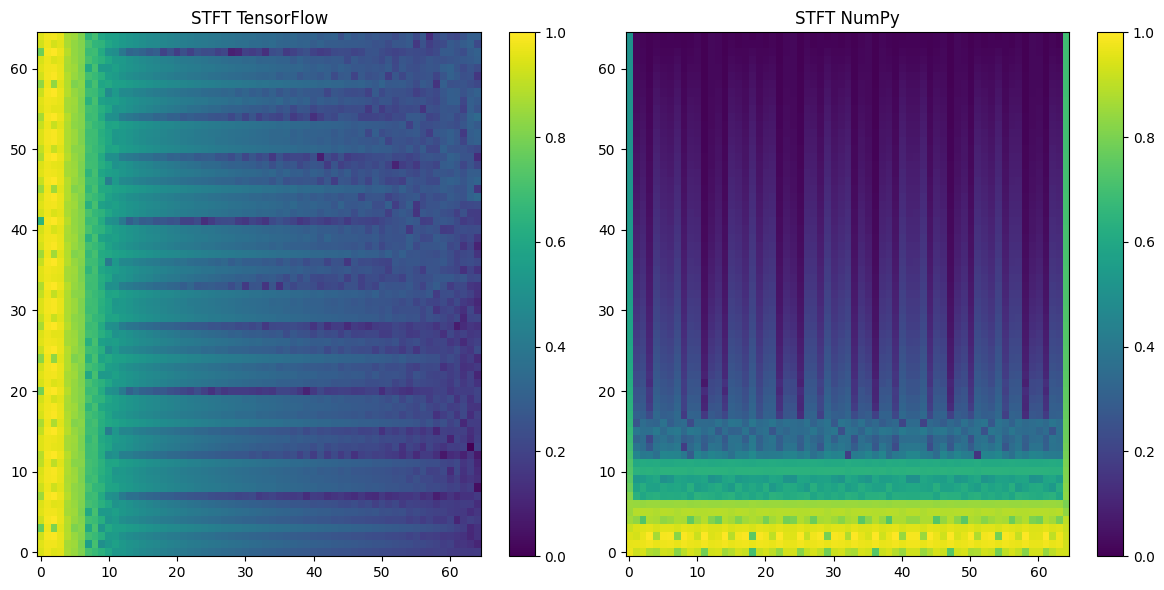

In [17]:
print("Error cuadratico medio (MSE):", tf.reduce_mean(tf.square(stft_tf - stft_np)))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(stft_tf.numpy(), aspect='auto', origin='lower', cmap='viridis')
plt.title('STFT TensorFlow')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(stft_np, aspect='auto', origin='lower', cmap='viridis')
plt.title('STFT NumPy')
plt.colorbar()
plt.tight_layout()
plt.show()